# Notebook 02: Agent-Based Model (ABM)
Implements network-based opinion updates (logit Hegselmann-Krause dynamics) and double-threshold social mobilization cascades (Granovetter) on small-world network topologies using Mesa.

### Important Project Safety Notice

Before executing or citing the findings in this notebook, please read the public guidance on what this project is and is not claiming:  

[docs/not_saying.md](../docs/not_saying.md) - *What This Theory Is NOT Claiming*

## Macro-Validation Targets
Before using the ABM findings, the simulation must pass three macro-validation tests:
1. **Temporal**: Under moderate delay ($\tau \ge 3$), the system must display sustained oscillation rather than lock-in.
2. **Structural**: Restricting bounded confidence interval $\epsilon$ must increase the policy swing amplitude (asymmetric echo chamber amplification).
3. **Threshold**: Backlash coalition size must show a non-linear jump (S-curve cascade) as policy distance from norm exceeds $\theta$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.fft as fft
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath('..'))
from src.pendulum_abm import PendulumABM, PolicyAgent

print("Libraries and ABM classes imported successfully.")

Libraries and ABM classes imported successfully.


## 1. Run Standard Simulation & Trajectory Visualization
Here we run the Agent-Based Model with a default small-world network configuration under moderate delay ($\tau=3$), demonstrating the emergent oscillation loops.

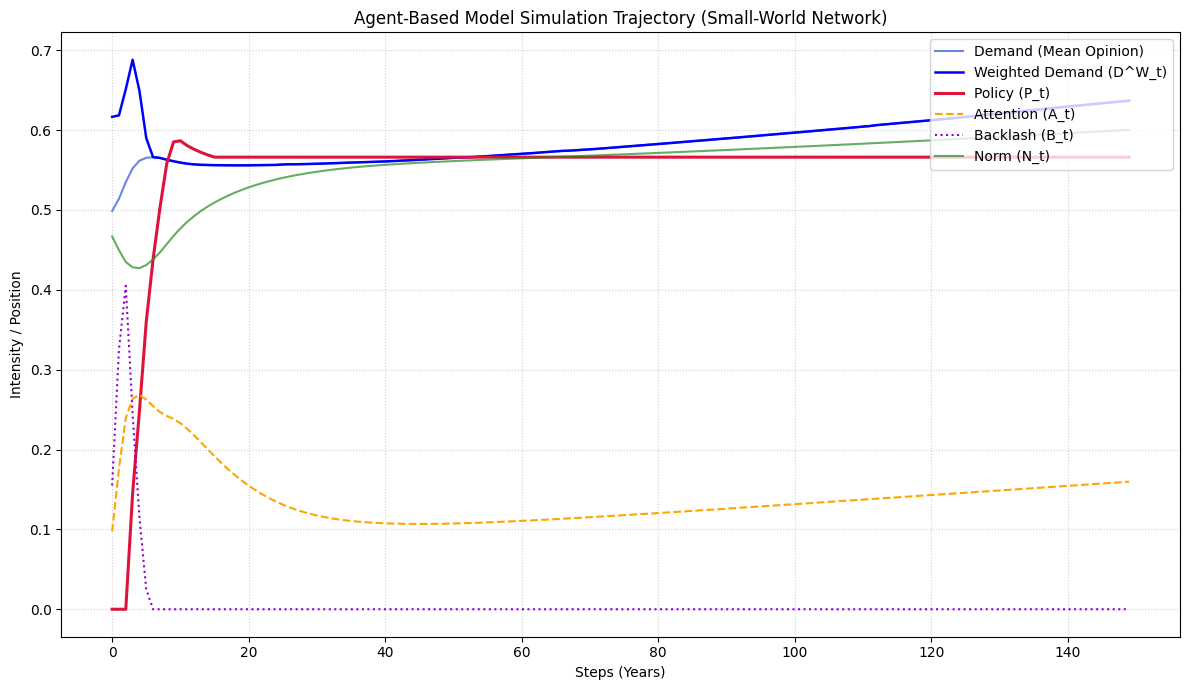

In [2]:
# Run PendulumABM for 150 steps
np.random.seed(42)
model = PendulumABM(N=200, network_type='small_world', tolerance=0.25, tau=3, lambda_=0.25,
                    alpha=0.15, beta=0.05, gamma=0.15, delta=0.25, phi=0.2, nu=0.04,
                    attention_diffusion=0.1, theta_inst=0.2, omega=3.0, kappa=0.0,
                    theta_mean=0.8, theta_std=0.15, psi_min=0.1, psi_max=0.3, initial_policy=0.0)

for _ in range(150):
    model.step()

df = model.datacollector.get_model_vars_dataframe()

# Plot the results
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(df.index, df["Demand"], label="Demand (Mean Opinion)", color="royalblue", alpha=0.8)
ax.plot(df.index, df["WeightedDemand"], label="Weighted Demand (D^W_t)", color="blue", linewidth=1.8)
ax.plot(df.index, df["Policy"], label="Policy (P_t)", color="crimson", linewidth=2.2)
ax.plot(df.index, df["Attention"], label="Attention (A_t)", color="orange", linestyle="--")
ax.plot(df.index, df["Backlash"], label="Backlash (B_t)", color="darkviolet", linestyle=":")
ax.plot(df.index, df["Norm"], label="Norm (N_t)", color="forestgreen", alpha=0.7)

ax.set_xlabel("Steps (Years)")
ax.set_ylabel("Intensity / Position")
ax.set_title("Agent-Based Model Simulation Trajectory (Small-World Network)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 2. Temporal Validation (Fourier Peak Analysis)
To test if the delay $\tau \ge 3$ creates sustained oscillations rather than lock-in, we run a long-run simulation ($T=500$) and compute the Power Spectral Density (PSD) using Fast Fourier Transform (FFT).

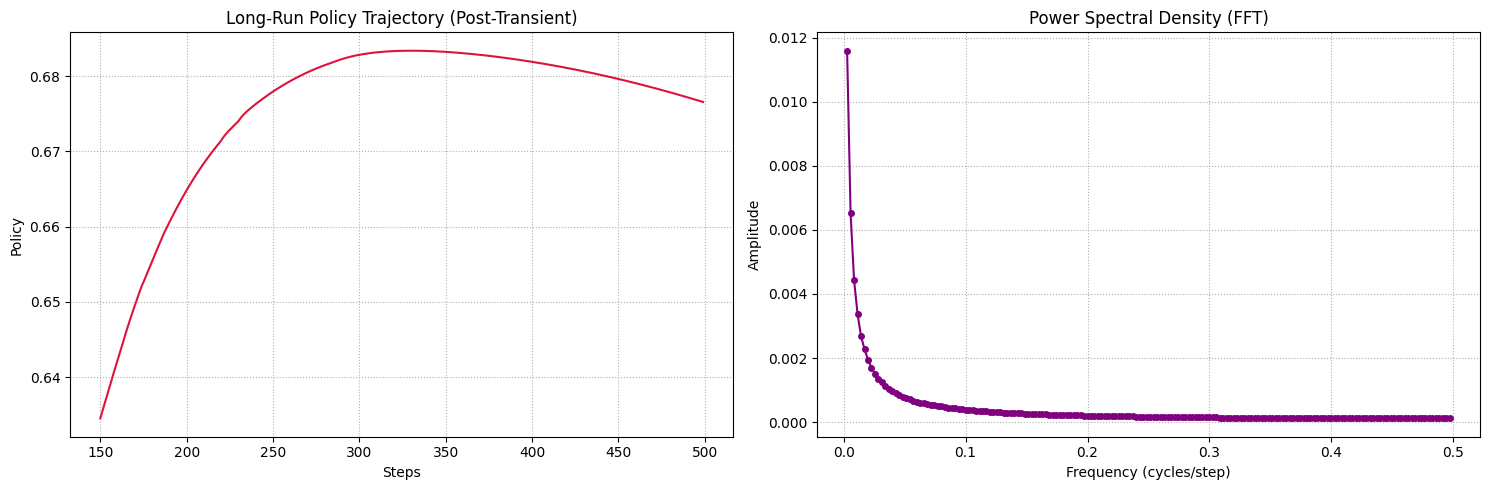

In [3]:
# Run long simulation for Fourier check
np.random.seed(10)
model_long = PendulumABM(N=200, network_type='small_world', tolerance=0.25, tau=4, lambda_=0.30,
                         alpha=0.2, beta=0.05, gamma=0.2, delta=0.25, phi=0.25, nu=0.03,
                         omega=3.0, theta_mean=0.8, theta_std=0.15, theta_inst=0.05)

for _ in range(500):
    model_long.step()

df_long = model_long.datacollector.get_model_vars_dataframe()
policy_series = df_long["Policy"].values[150:]  # Exclude initial transient

# Perform FFT
N_fft = len(policy_series)
yf = fft.fft(policy_series - np.mean(policy_series))
xf = fft.fftfreq(N_fft, 1.0)[:N_fft//2]
power = 2.0/N_fft * np.abs(yf[0:N_fft//2])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(df_long.index[150:], policy_series, color="crimson")
axes[0].set_title("Long-Run Policy Trajectory (Post-Transient)")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Policy")
axes[0].grid(True, linestyle=":")

axes[1].plot(xf[1:], power[1:], color="purple", marker="o", markersize=4) # Skip 0 frequency
axes[1].set_title("Power Spectral Density (FFT)")
axes[1].set_xlabel("Frequency (cycles/step)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, linestyle=":")
plt.tight_layout()
plt.show()

## 3. Structural Validation (Echo Chamber Amplification Sweep)
We sweep the bounded confidence interval parameter $\epsilon$ from $0.05$ (highly polarized caucuses) to $0.50$ (integrated mixing). We verify that narrowing tolerance $\epsilon$ increases the standard deviation of policy swings.

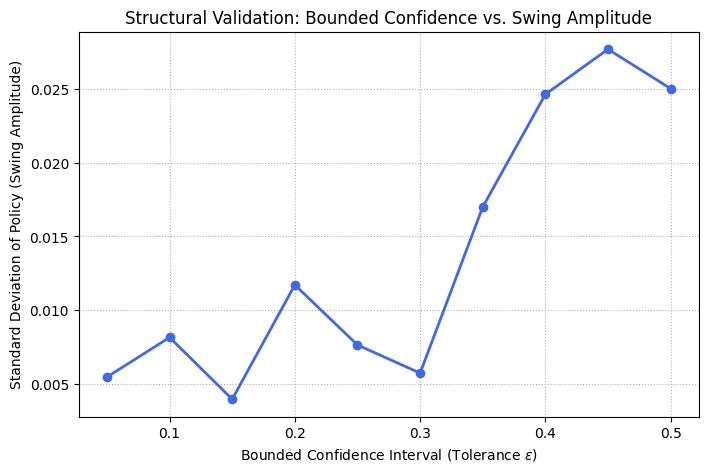

In [4]:
# Sweep tolerance (epsilon)
eps_range = np.linspace(0.05, 0.50, 10)
amplitudes = []

for eps in eps_range:
    np.random.seed(42)
    model_sweep = PendulumABM(N=150, network_type='small_world', tolerance=eps, tau=3, lambda_=0.25,
                              alpha=0.15, beta=0.05, gamma=0.15, delta=0.25, phi=0.2, nu=0.04,
                              omega=3.0, theta_mean=0.8, theta_inst=0.05)
    for _ in range(200):
        model_sweep.step()
    df_sweep = model_sweep.datacollector.get_model_vars_dataframe()
    p_last = df_sweep["Policy"].values[100:]  # analyze post-transient range
    amplitudes.append(np.std(p_last))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_range, amplitudes, marker="o", color="royalblue", linewidth=2)
ax.set_xlabel("Bounded Confidence Interval (Tolerance $\epsilon$)")
ax.set_ylabel("Standard Deviation of Policy (Swing Amplitude)")
ax.set_title("Structural Validation: Bounded Confidence vs. Swing Amplitude")
ax.grid(True, linestyle=":")
plt.show()

## 4. Threshold Validation (Granovetter S-Curve Cascade)
To verify the cascade mobilization kinetics, we freeze the policy update and sweep different levels of fixed policy. We plot the steady-state backlash size $B^*$ to verify the sigmoidal S-curve.

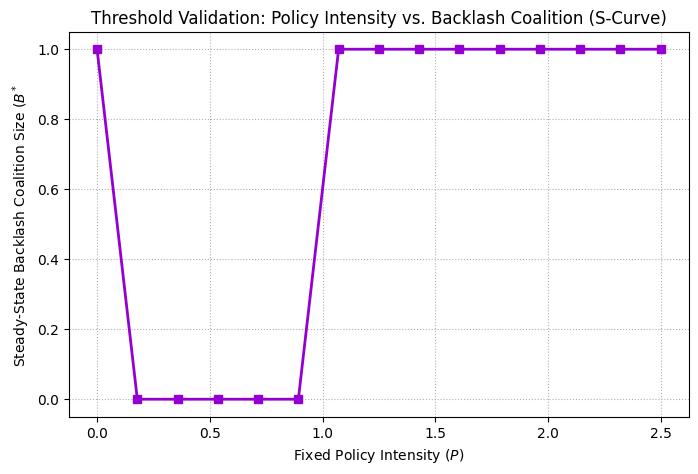

In [5]:
# Fixed policy sweeps to verify the S-curve backlash activation cascade
p_fixed_range = np.linspace(0.0, 2.5, 15)
backlash_steady_state = []

for p_val in p_fixed_range:
    np.random.seed(42)
    model_cascade = PendulumABM(N=200, network_type='small_world', tolerance=0.25, tau=3, lambda_=0.0,
                                alpha=0.15, beta=0.05, gamma=0.15, delta=0.25, phi=0.2, nu=0.0,
                                theta_mean=1.0, theta_std=0.15, psi_min=0.15, psi_max=0.35, initial_policy=p_val)
    for _ in range(50):
        model_cascade.step()
        model_cascade.policy = p_val # enforce policy fixity
        
    df_c = model_cascade.datacollector.get_model_vars_dataframe()
    backlash_steady_state.append(df_c["Backlash"].values[-1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_fixed_range, backlash_steady_state, marker="s", color="darkviolet", linewidth=2)
ax.set_xlabel("Fixed Policy Intensity ($P$)")
ax.set_ylabel("Steady-State Backlash Coalition Size ($B^*$")
ax.set_title("Threshold Validation: Policy Intensity vs. Backlash Coalition (S-Curve)")
ax.grid(True, linestyle=":")
plt.show()